In [1]:
!pip install -q tiktoken datasets pandas matplotlib psutil

In [2]:
import os
import time
import math
import json
import random
import shutil
import subprocess
import threading
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import tiktoken
from datasets import load_dataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)
    print("CUDA:", torch.version.cuda)
    print("PyTorch:", torch.__version__)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM GB: 47.98779296875
CUDA: 12.1
PyTorch: 2.5.1+cu121


In [3]:
# CELL 3 — Updated config for Experiment 14: Large Scaling with Weight Tying + SwiGLU

RUN_NAME = "logos_exp14_large_scaling_weight_tying_swiglu"

OUT_DIR = Path("./logos_runs") / RUN_NAME
DATA_DIR = Path("./data")

OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_CACHE = DATA_DIR / "openwebtext_subset_100k.txt"

# Data
# Increased from 50,000 to 100,000 samples for larger-scale training.
OWT_SAMPLES = 100_000

# Model
# Large-scale Logos model using the proven recipe:
# Weight Tying + SwiGLU + Decoder-only GPT
BATCH_SIZE = 32
BLOCK_SIZE = 512
N_EMBD = 768
N_HEAD = 12
N_LAYER = 12
DROPOUT = 0.2

# SwiGLU hidden size
# SwiGLU uses 3 projections, so 8/3 * N_EMBD keeps FFN params near standard FFN scale.
SWIGLU_HIDDEN = int((8 * N_EMBD) / 3)

# Training
MAX_ITERS = 3000
EVAL_INTERVAL = 300
EVAL_ITERS = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
GRAD_CLIP = 1.0
WARMUP_ITERS = 150
MIN_LR_RATIO = 0.05

# Generation
GENERATE_TOKENS = 250
TEMPERATURE = 0.9
TOP_K = 40
TOP_P = 0.9

BEST_MODEL_PATH = OUT_DIR / "logos_large_scaling_weight_tying_swiglu_best.pt"
METRICS_PATH = OUT_DIR / "large_scaling_weight_tying_swiglu_metrics.csv"
SUMMARY_PATH = OUT_DIR / "large_scaling_weight_tying_swiglu_summary.json"

config = {
    "run_name": RUN_NAME,
    "experiment_type": "large_scaling_weight_tying_swiglu",
    "seed": SEED,
    "owt_samples": OWT_SAMPLES,
    "batch_size": BATCH_SIZE,
    "block_size": BLOCK_SIZE,
    "tokens_per_step": BATCH_SIZE * BLOCK_SIZE,
    "n_embd": N_EMBD,
    "n_head": N_HEAD,
    "head_dim": N_EMBD // N_HEAD,
    "n_layer": N_LAYER,
    "dropout": DROPOUT,
    "ffn_type": "SwiGLU",
    "swiglu_hidden": SWIGLU_HIDDEN,
    "normalization": "LayerNorm",
    "weight_tying": True,
    "scaling_phase": True,
    "scale_level": "large",
    "max_iters": MAX_ITERS,
    "eval_interval": EVAL_INTERVAL,
    "eval_iters": EVAL_ITERS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "warmup_iters": WARMUP_ITERS,
    "min_lr_ratio": MIN_LR_RATIO,
    "generate_tokens": GENERATE_TOKENS,
    "temperature": TEMPERATURE,
    "top_k": TOP_K,
    "top_p": TOP_P,
}

print(json.dumps(config, indent=2))

{
  "run_name": "logos_exp14_large_scaling_weight_tying_swiglu",
  "experiment_type": "large_scaling_weight_tying_swiglu",
  "seed": 42,
  "owt_samples": 100000,
  "batch_size": 32,
  "block_size": 512,
  "tokens_per_step": 16384,
  "n_embd": 768,
  "n_head": 12,
  "head_dim": 64,
  "n_layer": 12,
  "dropout": 0.2,
  "ffn_type": "SwiGLU",
  "swiglu_hidden": 2048,
  "normalization": "LayerNorm",
  "weight_tying": true,
  "scaling_phase": true,
  "scale_level": "large",
  "max_iters": 3000,
  "eval_interval": 300,
  "eval_iters": 50,
  "learning_rate": 0.0003,
  "weight_decay": 0.1,
  "grad_clip": 1.0,
  "warmup_iters": 150,
  "min_lr_ratio": 0.05,
  "generate_tokens": 250,
  "temperature": 0.9,
  "top_k": 40,
  "top_p": 0.9
}


In [4]:
# CELL 4 — Load OpenWebText subset without clean filtering

if not DATA_CACHE.exists():
    print("Downloading OpenWebText subset...")
    
    dataset = load_dataset("openwebtext", split="train", streaming=True)
    
    samples = []
    
    for i, sample in enumerate(dataset):
        if i >= OWT_SAMPLES:
            break
        
        text_piece = sample.get("text", "")
        
        if isinstance(text_piece, str) and len(text_piece.strip()) > 100:
            samples.append(text_piece.strip())
    
    text = "\n\n".join(samples)
    
    with open(DATA_CACHE, "w", encoding="utf-8") as f:
        f.write(text)
    
    print(f"Saved {len(samples)} samples to {DATA_CACHE}")

else:
    print("Loading cached original OpenWebText subset...")
    
    with open(DATA_CACHE, "r", encoding="utf-8") as f:
        text = f.read()

print("Characters:", len(text))
print("\nPreview:\n")
print(text[:500])

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Saved 100000 samples to data\openwebtext_subset_100k.txt
Characters: 492672887

Preview:

Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.

The decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.

CNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the B


In [5]:
enc = tiktoken.get_encoding("gpt2")
vocab_size = enc.n_vocab

def encode(s):
    return enc.encode_ordinary(s)

def decode(ids):
    return enc.decode(ids)

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Vocab size:", vocab_size)
print("Total tokens:", len(data))
print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

assert len(train_data) > BLOCK_SIZE + 1
assert len(val_data) > BLOCK_SIZE + 1

Vocab size: 50257
Total tokens: 113063536
Train tokens: 101757182
Val tokens: 11306354


In [6]:
def get_batch(split):
    source = train_data if split == "train" else val_data
    
    ix = torch.randint(
        low=0,
        high=len(source) - BLOCK_SIZE - 1,
        size=(BATCH_SIZE,)
    )
    
    x = torch.stack([source[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([source[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    
    return x.to(device), y.to(device)

xb, yb = get_batch("train")

print("x shape:", xb.shape)
print("y shape:", yb.shape)

x shape: torch.Size([32, 512])
y shape: torch.Size([32, 512])


In [7]:
# CELL 7 — GPT-style decoder-only model for Experiment 14: Large Scaling + Weight Tying + SwiGLU

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()

        assert n_embd % n_head == 0

        self.n_head = n_head
        self.head_dim = n_embd // n_head

        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = dropout
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        q, k, v = self.qkv(x).split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        y = F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True
        )

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.proj(y))

        return y


class SwiGLUFeedForward(nn.Module):
    def __init__(self, n_embd, hidden_dim, dropout):
        super().__init__()

        self.gate_proj = nn.Linear(n_embd, hidden_dim)
        self.up_proj = nn.Linear(n_embd, hidden_dim)
        self.down_proj = nn.Linear(hidden_dim, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gate = F.silu(self.gate_proj(x))
        value = self.up_proj(x)

        x = gate * value
        x = self.down_proj(x)
        x = self.dropout(x)

        return x


class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head, dropout, swiglu_hidden):
        super().__init__()

        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, dropout)

        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = SwiGLUFeedForward(n_embd, swiglu_hidden, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class LogosLargeScalingWeightTiedSwiGLULM(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding = nn.Embedding(BLOCK_SIZE, N_EMBD)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(N_EMBD, N_HEAD, DROPOUT, SWIGLU_HIDDEN)
                for _ in range(N_LAYER)
            ]
        )

        self.ln_f = nn.LayerNorm(N_EMBD)

        # Output head without bias for clean weight tying.
        self.lm_head = nn.Linear(N_EMBD, vocab_size, bias=False)

        self.apply(self._init_weights)

        # Weight tying:
        # Output projection shares the same tensor as token embedding.
        self.lm_head.weight = self.token_embedding.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)

        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            loss = F.cross_entropy(
                logits.view(B * T, vocab_size),
                targets.view(B * T)
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                k = min(top_k, logits.size(-1))
                top_values, _ = torch.topk(logits, k)
                logits[logits < top_values[:, [-1]]] = float("-inf")

            if top_p is not None and top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0

                sorted_logits[sorted_indices_to_remove] = float("-inf")
                logits = torch.zeros_like(logits).scatter(1, sorted_indices, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        return idx


model = LogosLargeScalingWeightTiedSwiGLULM().to(device)

param_count = sum(p.numel() for p in model.parameters())
trainable_param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

weight_tying_active = model.lm_head.weight.data_ptr() == model.token_embedding.weight.data_ptr()

print(model)
print(f"\nTotal parameters: {param_count:,}")
print(f"Trainable parameters: {trainable_param_count:,}")

print("Experiment: Large Scaling")
print("Base recipe: Weight Tying + SwiGLU")
print("Layers:", N_LAYER)
print("Embedding dimension:", N_EMBD)
print("Attention heads:", N_HEAD)
print("Head dimension:", N_EMBD // N_HEAD)
print("Context length:", BLOCK_SIZE)
print("Batch size:", BATCH_SIZE)
print("Tokens per step:", BATCH_SIZE * BLOCK_SIZE)
print("FFN type: SwiGLU")
print("SwiGLU hidden size:", SWIGLU_HIDDEN)
print("Normalization used: LayerNorm")
print("Weight tying active:", weight_tying_active)

LogosLargeScalingWeightTiedSwiGLULM(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(512, 768)
  (blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (resid_dropout): Dropout(p=0.2, inplace=False)
      )
      (ln2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (ffn): SwiGLUFeedForward(
        (gate_proj): Linear(in_features=768, out_features=2048, bias=True)
        (up_proj): Linear(in_features=768, out_features=2048, bias=True)
        (down_proj): Linear(in_features=2048, out_features=768, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
    )
    (1): TransformerBlock(
      (ln1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
       

In [8]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    
    for split in ["train", "val"]:
        losses = []
        
        for _ in range(EVAL_ITERS):
            xb, yb = get_batch(split)
            
            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(device == "cuda")
            ):
                _, loss = model(xb, yb)
            
            losses.append(loss.item())
        
        out[split] = float(np.mean(losses))
    
    model.train()
    return out


def checkpoint_size_mb(path):
    path = Path(path)
    if path.exists():
        return path.stat().st_size / (1024 ** 2)
    return None


@torch.no_grad()
def benchmark_generation_latency(prompt="The future of language models", max_new_tokens=100):
    model.eval()
    
    input_ids = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )
    
    if device == "cuda":
        torch.cuda.synchronize()
    
    start = time.time()
    
    out = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        temperature=TEMPERATURE,
        top_k=TOP_K,
        top_p=TOP_P
    )
    
    if device == "cuda":
        torch.cuda.synchronize()
    
    elapsed = time.time() - start
    
    ms_per_token = (elapsed / max_new_tokens) * 1000
    tokens_per_sec = max_new_tokens / elapsed
    
    return {
        "generation_elapsed_sec": elapsed,
        "generation_ms_per_token": ms_per_token,
        "generation_tokens_per_sec": tokens_per_sec,
        "sample_text": decode(out[0].tolist())
    }


def get_gpu_power_watts():
    try:
        result = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=power.draw",
                "--format=csv,noheader,nounits"
            ],
            encoding="utf-8"
        )
        return float(result.strip().split("\n")[0])
    except Exception:
        return None


class PowerMonitor:
    def __init__(self, interval=2.0):
        self.interval = interval
        self.samples = []
        self.running = False
        self.thread = None
    
    def _sample_loop(self):
        while self.running:
            p = get_gpu_power_watts()
            if p is not None:
                self.samples.append((time.time(), p))
            time.sleep(self.interval)
    
    def start(self):
        self.running = True
        self.thread = threading.Thread(target=self._sample_loop)
        self.thread.daemon = True
        self.thread.start()
    
    def stop(self):
        self.running = False
        
        if self.thread is not None:
            self.thread.join(timeout=1)
        
        if len(self.samples) == 0:
            return {
                "avg_gpu_power_watts": None,
                "estimated_gpu_energy_wh": None,
                "power_samples": 0
            }
        
        times = np.array([s[0] for s in self.samples])
        powers = np.array([s[1] for s in self.samples])
        
        duration_hours = (times[-1] - times[0]) / 3600 if len(times) > 1 else 0
        
        return {
            "avg_gpu_power_watts": float(np.mean(powers)),
            "estimated_gpu_energy_wh": float(np.mean(powers) * duration_hours),
            "power_samples": int(len(self.samples))
        }


print("Evaluation helpers ready.")

Evaluation helpers ready.


In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

def lr_lambda(step):
    if step < WARMUP_ITERS:
        return float(step + 1) / float(max(1, WARMUP_ITERS))
    
    progress = (step - WARMUP_ITERS) / float(max(1, MAX_ITERS - WARMUP_ITERS))
    progress = min(max(progress, 0.0), 1.0)
    
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    
    return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

scaler = torch.amp.GradScaler(
    device="cuda",
    enabled=(device == "cuda")
)

print("Optimizer ready.")
print("Initial LR:", optimizer.param_groups[0]["lr"])

Optimizer ready.
Initial LR: 2e-06


In [10]:
metrics_log = []

best_val_loss = float("inf")
best_iter = -1

tokens_seen = 0

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

power_monitor = PowerMonitor(interval=2.0)
power_monitor.start()

start_time = time.time()

model.train()

for iter_idx in range(MAX_ITERS + 1):
    
    if iter_idx % EVAL_INTERVAL == 0 or iter_idx == MAX_ITERS:
        losses = estimate_loss()
        
        elapsed_sec = time.time() - start_time
        elapsed_min = elapsed_sec / 60
        
        train_loss = losses["train"]
        val_loss = losses["val"]
        val_ppl = math.exp(val_loss) if val_loss < 20 else float("inf")
        
        tokens_per_sec = tokens_seen / elapsed_sec if elapsed_sec > 0 else 0
        
        peak_vram_mb = None
        if device == "cuda":
            peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        
        approx_train_flops = 6 * param_count * tokens_seen
        approx_train_pflops = approx_train_flops / 1e15
        
        row = {
            "iter": iter_idx,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_perplexity": val_ppl,
            "lr": optimizer.param_groups[0]["lr"],
            "elapsed_min": elapsed_min,
            "tokens_seen": tokens_seen,
            "tokens_per_sec": tokens_per_sec,
            "peak_vram_mb": peak_vram_mb,
            "param_count": param_count,
            "approx_train_pflops": approx_train_pflops
        }
        
        metrics_log.append(row)
        
        print(
            f"iter {iter_idx:5d} | "
            f"train {train_loss:.4f} | "
            f"val {val_loss:.4f} | "
            f"ppl {val_ppl:.2f} | "
            f"tok/s {tokens_per_sec:.0f} | "
            f"VRAM {peak_vram_mb:.0f} MB"
        )
        
        pd.DataFrame(metrics_log).to_csv(METRICS_PATH, index=False)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_iter = iter_idx
            
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "config": config,
                    "param_count": param_count,
                    "best_val_loss": best_val_loss,
                    "best_iter": best_iter,
                    "vocab_size": vocab_size,
                    "tokenizer": "gpt2"
                },
                BEST_MODEL_PATH
            )
            
            print(f"Saved new best checkpoint at iter {iter_idx}")
    
    if iter_idx == MAX_ITERS:
        break
    
    xb, yb = get_batch("train")
    
    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=(device == "cuda")
    ):
        _, loss = model(xb, yb)
    
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    
    tokens_seen += BATCH_SIZE * BLOCK_SIZE


power_summary = power_monitor.stop()

total_elapsed_sec = time.time() - start_time

print("\nTraining complete.")
print("Best iter:", best_iter)
print("Best val loss:", best_val_loss)
print("Elapsed minutes:", total_elapsed_sec / 60)
print("Power summary:", power_summary)
print("Metrics saved to:", METRICS_PATH)
print("Best model saved to:", BEST_MODEL_PATH)

iter     0 | train 11.0255 | val 11.0282 | ppl 61585.44 | tok/s 0 | VRAM 7105 MB
Saved new best checkpoint at iter 0
iter   300 | train 6.3090 | val 6.3307 | ppl 561.53 | tok/s 64922 | VRAM 17727 MB
Saved new best checkpoint at iter 300
iter   600 | train 5.8321 | val 5.8922 | ppl 362.21 | tok/s 66200 | VRAM 17729 MB
Saved new best checkpoint at iter 600
iter   900 | train 5.5290 | val 5.5688 | ppl 262.11 | tok/s 66277 | VRAM 17729 MB
Saved new best checkpoint at iter 900
iter  1200 | train 5.2939 | val 5.3928 | ppl 219.81 | tok/s 66213 | VRAM 17729 MB
Saved new best checkpoint at iter 1200
iter  1500 | train 5.1328 | val 5.2105 | ppl 183.19 | tok/s 66141 | VRAM 17729 MB
Saved new best checkpoint at iter 1500
iter  1800 | train 5.0360 | val 5.0999 | ppl 164.00 | tok/s 66107 | VRAM 17729 MB
Saved new best checkpoint at iter 1800
iter  2100 | train 4.9194 | val 5.0039 | ppl 149.00 | tok/s 66083 | VRAM 17729 MB
Saved new best checkpoint at iter 2100
iter  2400 | train 4.8652 | val 4.9589 

In [11]:
# CELL 11 — Final benchmark for Experiment 14: Large Scaling + Weight Tying + SwiGLU

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

final_losses = estimate_loss()

final_train_loss = final_losses["train"]
final_val_loss = final_losses["val"]
final_val_ppl = math.exp(final_val_loss) if final_val_loss < 20 else float("inf")

latency_result = benchmark_generation_latency(
    prompt="The future of language models",
    max_new_tokens=100
)

ckpt_mb = checkpoint_size_mb(BEST_MODEL_PATH)

peak_vram_mb = None
if device == "cuda":
    peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

weight_tying_active = model.lm_head.weight.data_ptr() == model.token_embedding.weight.data_ptr()

summary = {
    "run_name": RUN_NAME,
    "model_type": "decoder_only_gpt_large_scaling_weight_tied_swiglu",
    "experiment_type": "large_scaling_weight_tying_swiglu",
    "tokenizer": "gpt2",
    "dataset": "openwebtext_subset_100k",
    "param_count": param_count,
    "trainable_param_count": trainable_param_count,
    "scaling_phase": True,
    "scale_level": "large",
    "n_layer": N_LAYER,
    "n_embd": N_EMBD,
    "n_head": N_HEAD,
    "head_dim": N_EMBD // N_HEAD,
    "context_length": BLOCK_SIZE,
    "batch_size": BATCH_SIZE,
    "tokens_per_step": BATCH_SIZE * BLOCK_SIZE,
    "ffn_type": "SwiGLU",
    "swiglu_hidden": SWIGLU_HIDDEN,
    "normalization": "LayerNorm",
    "weight_tying_active": weight_tying_active,
    "max_iters": MAX_ITERS,
    "best_iter": best_iter,
    "best_val_loss": best_val_loss,
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "final_val_perplexity": final_val_ppl,
    "checkpoint_size_mb": ckpt_mb,
    "peak_vram_mb": peak_vram_mb,
    "generation_ms_per_token": latency_result["generation_ms_per_token"],
    "generation_tokens_per_sec": latency_result["generation_tokens_per_sec"],
    "total_elapsed_sec": total_elapsed_sec,
    **power_summary,
    "config": config
}

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

print("\n=== SAMPLE GENERATION ===\n")
print(latency_result["sample_text"])

C:\Users\guest1\AppData\Local\Temp\ipykernel_34324\619163505.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(BEST_MODEL_PATH, map_location=device

{
  "run_name": "logos_exp14_large_scaling_weight_tying_swiglu",
  "model_type": "decoder_only_gpt_large_scaling_weight_tied_swiglu",
  "experiment_type": "large_scaling_weight_tying_swiglu",
  "tokenizer": "gpt2",
  "dataset": "openwebtext_subset_100k",
  "param_count": 124031232,
  "trainable_param_count": 124031232,
  "scaling_phase": true,
  "scale_level": "large",
  "n_layer": 12,
  "n_embd": 768,
  "n_head": 12,
  "head_dim": 64,
  "context_length": 512,
  "batch_size": 32,
  "tokens_per_step": 16384,
  "ffn_type": "SwiGLU",
  "swiglu_hidden": 2048,
  "normalization": "LayerNorm",
  "weight_tying_active": true,
  "max_iters": 3000,
  "best_iter": 3000,
  "best_val_loss": 4.920112733840942,
  "final_train_loss": 4.8511860561370845,
  "final_val_loss": 4.924353322982788,
  "final_val_perplexity": 137.60032989413122,
  "checkpoint_size_mb": 473.2024898529053,
  "peak_vram_mb": 17728.8759765625,
  "generation_ms_per_token": 15.12904405593872,
  "generation_tokens_per_sec": 66.0980294

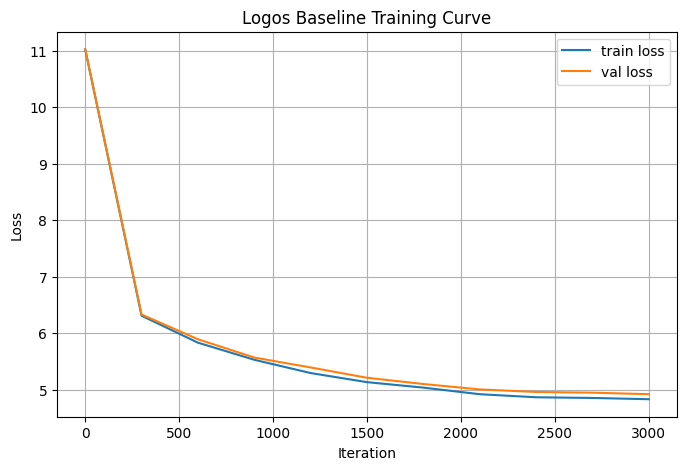

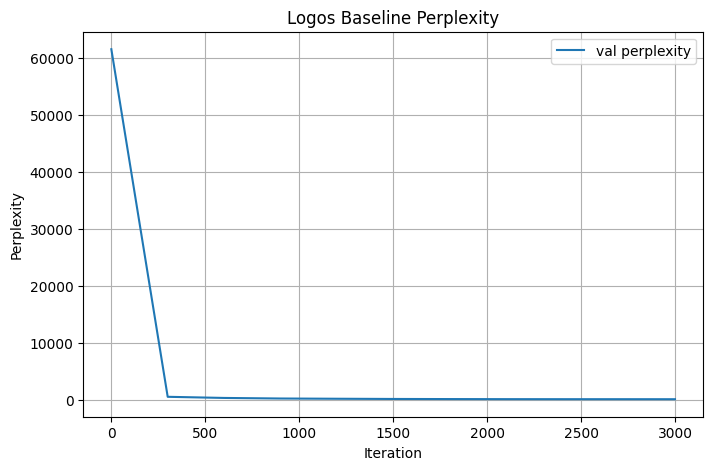

In [12]:
df = pd.read_csv(METRICS_PATH)

plt.figure(figsize=(8, 5))
plt.plot(df["iter"], df["train_loss"], label="train loss")
plt.plot(df["iter"], df["val_loss"], label="val loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Logos Baseline Training Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df["iter"], df["val_perplexity"], label="val perplexity")
plt.xlabel("Iteration")
plt.ylabel("Perplexity")
plt.title("Logos Baseline Perplexity")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# CELL 13 — Zip results for Experiment 14: Large Scaling + Weight Tying + SwiGLU

zip_path = shutil.make_archive(
    base_name="logos_exp14_large_scaling_weight_tying_swiglu_results",
    format="zip",
    root_dir="./logos_runs",
    base_dir=RUN_NAME
)

print("Zipped results:", zip_path)

Zipped results: C:\Users\guest1\Desktop\projojo\logos_exp14_large_scaling_weight_tying_swiglu_results.zip
